In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
import pandas as pd
import time
import joblib
from pathlib import Path
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import matplotlib.pyplot as plt

from src.preprocessing.cleaner import preprocess_for_tfidf
from src.features.tfidf import TFIDFVectorizer

In [3]:
train_df = pd.read_csv("../data/interim/train_split.csv")
valid_df = pd.read_csv("../data/interim/valid_split.csv")

C:\Users\fam-01\AppData\Local\Temp\ipykernel_2132\3517047404.py:1: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv("../data/interim/train_split.csv")
C:\Users\fam-01\AppData\Local\Temp\ipykernel_2132\3517047404.py:2: DtypeWarning: Columns (0: vote) have mixed types. Specify dtype option on import or set low_memory=False.
  valid_df = pd.read_csv("../data/interim/valid_split.csv")


In [6]:
train_df["clean_text"] = train_df["reviewText"].apply(preprocess_for_tfidf)
valid_df["clean_text"] = valid_df["reviewText"].apply(preprocess_for_tfidf)

In [4]:
tfidf = TFIDFVectorizer.load("../artifacts/vectorizers/tfidf.joblib")

In [7]:
X_train = tfidf.transform(train_df["clean_text"])
X_valid = tfidf.transform(valid_df["clean_text"])

In [8]:
y_train = train_df["overall"]
y_valid = valid_df["overall"]

In [18]:
y_train.value_counts().sort_index()

overall
1     66360
2     45405
3     64991
4    125211
5    369188
Name: count, dtype: int64

In [19]:
y_valid.value_counts().sort_index()

overall
1    16590
2    11351
3    16248
4    31303
5    92297
Name: count, dtype: int64

In [ ]:
start_time = time.time()

model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

In [ ]:
y_pred = model.predict(X_valid)

In [ ]:
accuracy = accuracy_score(y_valid, y_pred)

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.7065


In [ ]:
print(
    classification_report(
        y_valid,
        y_pred,
    )
)

              precision    recall  f1-score   support

           1       0.66      0.72      0.69     16590
           2       0.41      0.23      0.30     11351
           3       0.45      0.35      0.40     16248
           4       0.54      0.42      0.47     31303
           5       0.80      0.92      0.86     92297

    accuracy                           0.71    167789
   macro avg       0.57      0.53      0.54    167789
weighted avg       0.68      0.71      0.69    167789



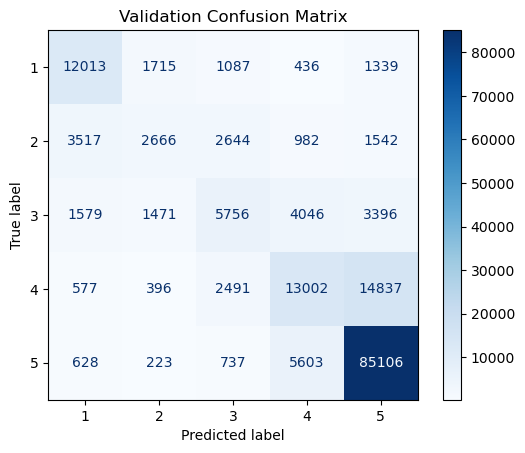

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_valid,
    y_pred,
    cmap="Blues",
)
plt.title("Validation Confusion Matrix")
plt.show()

In [ ]:
pd.Series(y_pred).value_counts()

5    106220
4     24069
1     18314
3     12715
2      6471
Name: count, dtype: int64

In [20]:
coef = model.coef_

In [21]:
coef.shape

(5, 50000)

In [23]:
models_dir = Path("../artifacts/models")
models_dir.mkdir(parents=True, exist_ok=True)

joblib.dump(
    model,
    models_dir / "logistic_regression.joblib",
)

['..\\artifacts\\models\\logistic_regression.joblib']

In [24]:
model_path = models_dir / "logistic_regression.joblib"

print(
    model_path.stat().st_size / 1024 / 1024,
    "MB",
)

1.9082326889038086 MB


Logistic Regression was trained using TF-IDF features extracted from the training data. The model serves as the baseline for all subsequent experiments. Validation performance will be compared with Linear SVM, Naive Bayes, and BERT-based models in later phases.